# 8-bit Quantization-Aware Training (QAT) on CIFAR-10

This notebook runs **QAT during training** (fake quantization) and then converts the trained model to **INT8** for inference.

It is inspired by `train_augmentation.py` but keeps the notebook lightweight by importing only helper functions (`_prepare_data`, `_save_plots`, and `progress_bar`) and defining a focused QAT loop here.

In [8]:
import os
import copy
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim

from models import ResNet18
from utils import progress_bar
from train_augmentation import _prepare_data, _save_plots

from torch.ao.quantization import get_default_qat_qconfig_mapping
from torch.ao.quantization.quantize_fx import prepare_qat_fx, convert_fx

torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [9]:
# Hyperparameters (edit as needed)
epochs = 10
lr = 0.01
batch_size_train = 128
batch_size_test = 100
num_workers = 2

# Optional pretrained weights (set to None to train from scratch)
pretrained_ckpt_path = 'Models Weights/Resnet18_V2.pth'

# Save naming
# run_name = f'resnet18_qat8_{datetime.now().strftime("%Y%m%d_%H%M%S")}'
run_name = 'ResNet18_INT8'
weights_dir = 'Models Weights'
plots_root_dir = 'Model Plots'
os.makedirs(weights_dir, exist_ok=True)
os.makedirs(plots_root_dir, exist_ok=True)

In [10]:
# Reuse data preparation from train_augmentation.py
trainloader, testloader = _prepare_data(
    batch_size_train=batch_size_train,
    batch_size_test=batch_size_test,
    num_workers=num_workers,
)

==> Preparing data..
Files already downloaded and verified
Files already downloaded and verified


In [11]:
# Build FP32 model and optionally load a checkpoint
fp32_model = ResNet18()

if pretrained_ckpt_path and os.path.exists(pretrained_ckpt_path):
    checkpoint = torch.load(pretrained_ckpt_path, map_location='cpu')
    state_dict = checkpoint['net'] if isinstance(checkpoint, dict) and 'net' in checkpoint else checkpoint
    state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
    missing, unexpected = fp32_model.load_state_dict(state_dict, strict=False)
    print(f'Loaded checkpoint: {pretrained_ckpt_path}')
    if missing:
        print('Missing keys:', missing)
    if unexpected:
        print('Unexpected keys:', unexpected)
else:
    print('No pretrained checkpoint loaded (training from scratch).')

fp32_model = fp32_model.to(device)

Loaded checkpoint: Models Weights/Resnet18_V2.pth


/tmp/ipykernel_3771819/4169056470.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(pretrained_ckpt_path, map_location='cpu')


In [12]:
# Prepare model for QAT (8-bit) using FX graph mode
supported_engines = torch.backends.quantized.supported_engines
if 'fbgemm' in supported_engines:
    quant_backend = 'fbgemm'
elif 'x86' in supported_engines:
    quant_backend = 'x86'
elif 'qnnpack' in supported_engines:
    quant_backend = 'qnnpack'
else:
    raise RuntimeError(f'No supported quantization backend found. Available: {supported_engines}')

torch.backends.quantized.engine = quant_backend
print(f'Quantization backend: {quant_backend}')

fp32_model.train()
qconfig_mapping = get_default_qat_qconfig_mapping(quant_backend)
example_inputs = (torch.randn(1, 3, 32, 32, device=device),)
qat_model = prepare_qat_fx(copy.deepcopy(fp32_model), qconfig_mapping, example_inputs)
qat_model = qat_model.to(device)
print('QAT model prepared.')

/opt/img/effdl-venv/lib/python3.12/site-packages/torch/ao/quantization/observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


Quantization backend: fbgemm
QAT model prepared.


In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(qat_model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

train_losses, train_accs = [], []
test_losses, test_accs = [], []
best_acc = 0.0
best_epoch = 0
best_state = None

def train_one_epoch(epoch):
    qat_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (inputs, targets) in enumerate(trainloader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = qat_model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        progress_bar(
            batch_idx,
            len(trainloader),
            'Loss: %.3f | Acc: %.3f%% (%d/%d)' % (
                running_loss / (batch_idx + 1),
                100.0 * correct / total,
                correct,
                total,
            ),
        )

    epoch_loss = running_loss / len(trainloader)
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, title='Eval'):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(loader):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

            progress_bar(
                batch_idx,
                len(loader),
                f'{title} Loss: %.3f | Acc: %.3f%% (%d/%d)' % (
                    running_loss / (batch_idx + 1),
                    100.0 * correct / total,
                    correct,
                    total,
                ),
            )

    return running_loss / len(loader), 100.0 * correct / total

In [14]:
for epoch in range(epochs):
    print(f'\nEpoch {epoch + 1}/{epochs}')
    tr_loss, tr_acc = train_one_epoch(epoch)
    te_loss, te_acc = evaluate(qat_model, testloader, title='QAT Test')

    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    test_losses.append(te_loss)
    test_accs.append(te_acc)

    if te_acc > best_acc:
        best_acc = te_acc
        best_epoch = epoch
        best_state = copy.deepcopy(qat_model.state_dict())

    scheduler.step()

print(f'Best QAT (fake-quant) test accuracy: {best_acc:.2f}% at epoch {best_epoch}')


Epoch 1/10
 [================================================================>]  Step: 148ms | Tot: 1m20s | Loss: 0.023 | Acc: 99.316% (49658/5000 391/391 1  
 [================================================================>]  Step: 67ms | Tot: 6s734ms | QAT Test Loss: 0.319 | Acc: 91.070% (9107/1000 100/100 

Epoch 2/10
 [================================================================>]  Step: 148ms | Tot: 1m20s | Loss: 0.071 | Acc: 97.712% (48856/5000 391/391 1  
 [================================================================>]  Step: 67ms | Tot: 6s704ms | QAT Test Loss: 0.284 | Acc: 91.670% (9167/1000 100/100 

Epoch 3/10
 [================================================================>]  Step: 148ms | Tot: 1m20s | Loss: 0.066 | Acc: 97.870% (48935/5000 391/391 1  
 [================================================================>]  Step: 67ms | Tot: 6s704ms | QAT Test Loss: 0.285 | Acc: 91.570% (9157/1000 100/100 

Epoch 4/10
 [============================================

In [15]:
# Restore best QAT state then convert to INT8
if best_state is not None:
    qat_model.load_state_dict(best_state)

qat_model.eval()
qat_model_cpu = qat_model.to('cpu')
int8_model = convert_fx(qat_model_cpu)
print('Converted to INT8 model.')

Converted to INT8 model.


In [16]:
# Evaluate INT8 model (CPU inference)
def evaluate_int8(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(loader):
            outputs = model(inputs.cpu())
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

            progress_bar(
                batch_idx,
                len(loader),
                'INT8 Eval Acc: %.3f%% (%d/%d)' % (100.0 * correct / total, correct, total),
            )

    return 100.0 * correct / total

int8_acc = evaluate_int8(int8_model, testloader)
print(f'INT8 test accuracy: {int8_acc:.2f}%')

 [================================================================>]  Step: 213ms | Tot: 24s783ms | INT8 Eval Acc: 95.200% (9520/1000 100/100 
INT8 test accuracy: 95.20%


In [17]:
# Save QAT and INT8 artifacts
qat_save_path = os.path.join(weights_dir, f'{run_name}_qat_best.pth')
int8_save_path = os.path.join(weights_dir, f'{run_name}_int8.pth')

torch.save({
    'net': best_state if best_state is not None else qat_model.state_dict(),
    'best_acc': best_acc,
    'best_epoch': best_epoch,
    'quantization': 'QAT 8-bit (fake quant during training)',
}, qat_save_path)

torch.save({
    'net': int8_model.state_dict(),
    'int8_acc': int8_acc,
    'quantization': 'INT8 converted from QAT',
}, int8_save_path)

print(f'Saved QAT checkpoint: {qat_save_path}')
print(f'Saved INT8 state_dict: {int8_save_path}')

Saved QAT checkpoint: Models Weights/ResNet18_INT8_qat_best.pth
Saved INT8 state_dict: Models Weights/ResNet18_INT8_int8.pth



==> Plotting training history...
Training history plot saved to Model Plots/ResNet18_INT8/training_history_augmix.png


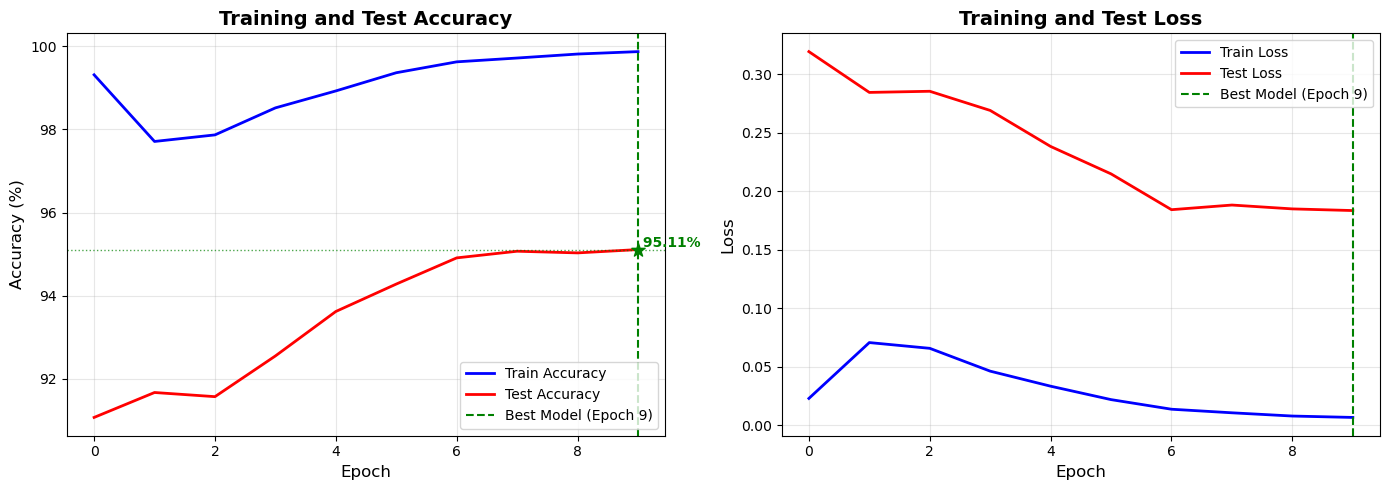

In [18]:
# Reuse plotting utility from train_augmentation.py
model_plot_dir = os.path.join(plots_root_dir, run_name)
os.makedirs(model_plot_dir, exist_ok=True)

_save_plots(
    train_accs=train_accs,
    test_accs=test_accs,
    train_losses=train_losses,
    test_losses=test_losses,
    best_epoch=best_epoch,
    best_acc=best_acc,
    start_epoch=0,
    epochs=epochs,
    model_plot_dir=model_plot_dir,
)

## Notes

- QAT inserts fake-quant modules during training to simulate 8-bit behavior.
- The final INT8 model is evaluated on CPU after `convert_fx`.
- If you want longer runs, increase `epochs` and optionally lower `lr` after a few epochs.